# Mapper Exploration Notebook
In this notebook, we:
- Load CLAP embeddings
- Define the Mapper MLP
- Generate dummy target audio parameters
- Train the model and visualize loss

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

# Add the root of the project (awol-audio/) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.mapping.mapper import MapperMLP

In [15]:
#Load CLAP embeddings from .npy files

embedding_dir = "../data/embeddings"

X = []
for file in os.listdir(embedding_dir):
    if file.endswith(".npy") and file.startswith("embedding_"):
        emb = np.load(os.path.join(embedding_dir, file))
        X.append(emb)

X = np.stack(X)
print(f"Loaded {X.shape[0]} embeddings with shape {X.shape[1]}")


Loaded 10 embeddings with shape 512


## Test 1 — Training with random dummy targets

In this first test, we generate completely random targets using `np.random.rand`, 
only to verify that the MLP architecture is capable of learning and reducing the loss.

This is **not realistic**, but useful as a baseline for testing the model's capacity to fit arbitrary data.

In [10]:
# Create dummy target audio parameters

# Let's assume we want to generate 128 output parameters per embedding (e.g. pitch, loudness, timbre, etc.)
Y = np.random.rand(X.shape[0], 128)
print(f"Dummy targets shape: {Y.shape}")


Dummy targets shape: (10, 128)


## Test 2 — Training with synthetic audio-like targets

In this second test, we simulate more realistic audio-related parameters such as:
- `f0` (pitch): sinusoidal curve
- `amplitude`: exponential decay
- `harmonic distribution`: Gaussian shape across harmonics

We concatenate these into a 128-dimensional target and train the same MLP on this new structure.


In [18]:
# Generate synthetic but realistic audio-like targets

import math

n_samples = X.shape[0]
t = np.linspace(0, 1, 128)

Y = []

for i in range(n_samples):
    # Simulate f0 as a sine wave with phase shift
    f0 = 0.5 * np.sin(2 * np.pi * t * (i+1)) + 0.5
    
    # Simulate amplitude as a smooth exponential decay
    amplitude = np.exp(-5 * t)
    
    # Simulate harmonic_distribution as a Gaussian centered at 1/3
    center = int(len(t) * 0.33)
    harmonic = np.exp(-0.5 * ((np.arange(128) - center) / 15) ** 2)
    harmonic = harmonic / harmonic.sum()  # Normalize

    # Concatenate [f0 | amp | harmonic]
    sample = np.concatenate([f0[:32], amplitude[:32], harmonic[:64]])
    Y.append(sample)

Y = np.stack(Y)
print(f"Generated realistic synthetic targets with shape: {Y.shape}")


Generated realistic synthetic targets with shape: (10, 128)


In [19]:
# Instantiate the Mapper MLP model

model = MapperMLP(input_dim=512, hidden_dim=256, output_dim=128)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [20]:
# Train the model on the dummy data

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

n_epochs = 200
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, Y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}")


Epoch 0: Loss = 0.2167
Epoch 20: Loss = 0.0402
Epoch 40: Loss = 0.0276
Epoch 60: Loss = 0.0233
Epoch 80: Loss = 0.0131
Epoch 100: Loss = 0.0072
Epoch 120: Loss = 0.0061
Epoch 140: Loss = 0.0052
Epoch 160: Loss = 0.0048
Epoch 180: Loss = 0.0050


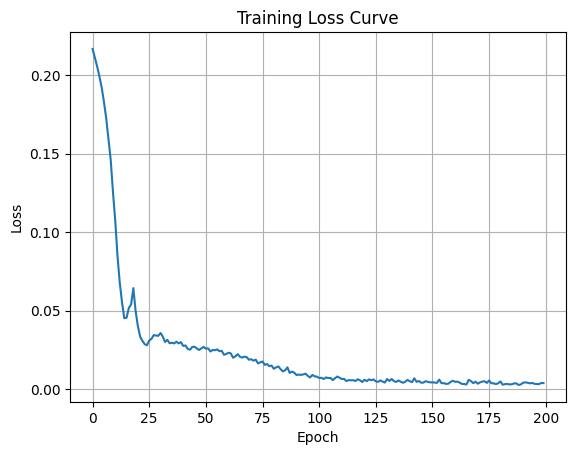

In [21]:
# Plot training loss

plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()
